<a href="https://colab.research.google.com/github/indahkhairunnisah-afk/Tugas-Pemodelaan-Simulasi-dan-Optimaasi/blob/main/Tugas_3_Slide%2021_Pemodelan%2C_Simulasi_dan_Optimasi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Tugas 4**

Sebuah mesin memiliki waktu antar kegagalan yang mengikuti distribusi Eksponensial dengan: Rata-rata waktu antar kegagalan: 50 jam (λ = 1/50)
1. Gunakan distribusi Eksponensial untuk mensimulasikan waktu kegagalan untuk 20 mesin selama 500 jam operasi.
2. Buat histogram waktu antar kegagalan berdasarkan hasil simulasi.
3. Hitung rata-rata dan median waktu antar kegagalan berdasarkan hasil simulasi.
4. Jika perusahaan hanya dapat menangani maksimal 3 kegagalan per hari, apakah kapasitas perawatan cukup?

#1. Menggunakan distribusi Eksponensial untuk mensimulasikan waktu kegagalan untuk 20 mesin selama 500 jam operasi.

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [104]:
mean_waktu = 50   # rata-rata waktu antar kegagalan (jam)
lambda_rate = 1 / 50 # λ = 1/50
num_mesin = 20
simulation_time = 500  # total jam operasi

mean_waktu adalah asumsi dasar distribusi eksponensial yang menggambarkan jarak waktu antar kegagalan.Dalam simulasi kegagalan mesin, kita berangkat dari asumsi bahwa rata‑rata waktu antar kegagalan adalah 50 jam. Artinya, secara statistik setiap mesin akan mengalami satu kali kegagalan setelah beroperasi selama 50 jam. Dari nilai rata‑rata ini, kita turunkan parameter distribusi eksponensial berupa laju kegagalan, yaitu
𝜆=1/50 = 0,02, Nilai ini menunjukkan bahwa dalam setiap jam, peluang sebuah mesin mengalami kegagalan adalah sekitar 2%.

Simulasi dilakukan menggunakan 20 mesin sekaligus dengan waktu operasi selama 500 jam, ini memungkinkan pengamatan beberapa kali kegagalan terjadi, distribusinya dan kapasistas perawatan yang tersedia mampu menangani kegagalan tesebut.

In [81]:
np.random.seed(42)  # untuk reproduksibilitas
failure_times = []

for machine in range(num_machines):
    total_time = 0
    while total_time < simulation_time:
        inter_failure = np.random.exponential(scale=mean_time)
        total_time += inter_failure
        if total_time <= simulation_time:
            failure_times.append(inter_failure)

Mensimulasikan bagaimana setiap mesin mengalami kegagalan berulang selama 500 jam, dengan jarak antar kegagalan acak mengikuti distribusi eksponensial, lalu menyimpan semua data kegagalan untuk dianalisis lebih lanjut. np.random.seed(42) dipakai agar hasil simulasi selalu konsisten setiap kali dijalankan. Kemudian dibuat list kosong failure_times untuk menampung data waktu antar kegagalan.

Kemudian dilakukan perulangan untuk setiap mesin. Setiap mesin dimulai dengan waktu operasi nol (total_time = 0) dan terus dijalankan hingga mencapai batas simulasi 500 jam. Di dalam perulangan, waktu antar kegagalan dihasilkan secara acak menggunakan distribusi eksponensial dengan rata‑rata 50 jam (np.random.exponential(scale=mean_time)). Nilai ini ditambahkan ke total waktu operasi mesin. Jika total waktu masih berada dalam periode simulasi, maka waktu antar kegagalan tersebut disimpan ke dalam list failure_times.

#2.  Memvisualisasikan waktu antar kegagalan berdasarkan hasil simulasi dengan histogram.

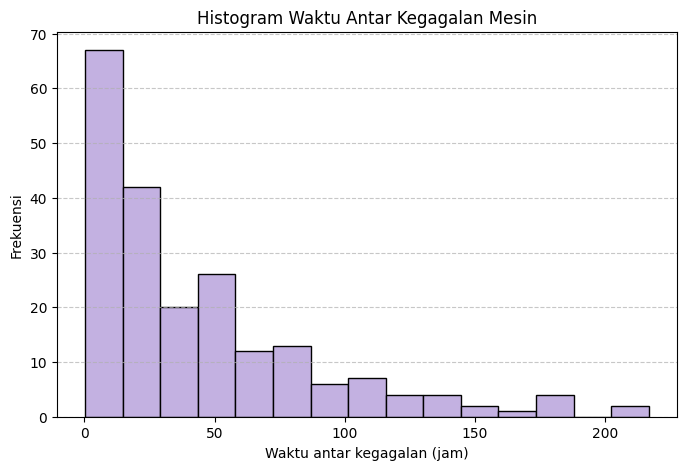

In [90]:
plt.figure(figsize=(8, 5))
plt.hist(failure_times, bins=15, color='#C3B1E1', edgecolor='black')
plt.xlabel("Waktu antar kegagalan (jam)")
plt.ylabel("Frekuensi")
plt.title("Histogram Waktu Antar Kegagalan Mesin")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

Grafik histogram menunjukkan bahwa sebagian besar kegagalan mesin terjadi pada interval waktu yang pendek (sekitar 0–20 jam), dengan frekuensi menurun seiring bertambahnya waktu antar kegagalan. Pola ini sesuai dengan sifat distribusi eksponensial: kegagalan lebih sering terjadi lebih cepat, sementara semakin jarang terjadi pada interval waktu yang panjang.

# 3. Menghitung rata-rata dan median waktu antar kegagalan berdasarkan hasil simulasi.

In [91]:
mean_failure = np.mean(failure_times)
median_failure = np.median(failure_times)

print("Rata-rata waktu antar kegagalan:", mean_failure)
print("Median waktu antar kegagalan:", median_failure)

Rata-rata waktu antar kegagalan: 43.85646897960751
Median waktu antar kegagalan: 26.713882395033597


Rata‑rata waktu antar kegagalan sebesar 43,86 jam menunjukkan bahwa mesin secara umum cenderung gagal lebih cepat daripada asumsi awal 50 jam. Sementara median sebesar 26,71 jam berarti separuh kegagalan terjadi dalam waktu kurang dari 27 jam. Hal ini menandakan distribusi data condong ke interval pendek, sehingga banyak kegagalan terjadi lebih cepat, meskipun ada beberapa kasus dengan interval panjang yang membuat nilai rata‑rata lebih tinggi.

#4. Analisis dilakukan untuk menguji apakah kapasitas perawatan (C) mampu mengakomodir kegagalan frekuensi harian dengan batasan$k \le 3$.

In [92]:
kegagalan_per_hari = len(failure_times) / (simulation_time / 24)
print("Rata-rata kegagalan per hari:", kegagalan_per_hari)

if kegagalan_per_hari <= 3:
    print("Kapasitas perawatan cukup")
else:
    print("Kapasitas perawatan tidak cukup")

Rata-rata kegagalan per hari: 10.08
Kapasitas perawatan tidak cukup


Dengan rata‑rata kegagalan per hari sebesar 10,08, berarti dalam simulasi 20 mesin selama 500 jam, setiap harinya terjadi sekitar 10 kali kegagalan. Angka ini jauh melebihi kapasitas perawatan yang hanya mampu menangani maksimal 3 kegagalan per hari. frekuensi kegagalan mesin terlalu tinggi dibanding kemampuan tim perawatan.

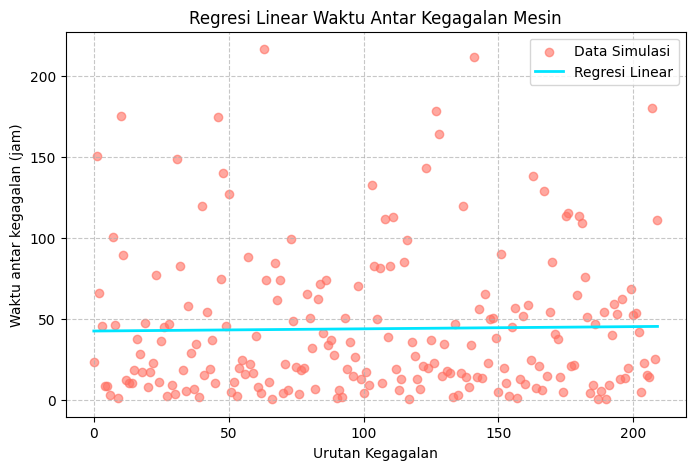

In [102]:
X = np.array(range(len(failure_times))).reshape(-1, 1)  # urutan kegagalan
y = np.array(failure_times)  # waktu antar kegagalan

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='#FF6F61', alpha=0.6, label="Data Simulasi")
plt.plot(X, y_pred, color='#00E5FF', linewidth=2, label="Regresi Linear")

plt.xlabel("Urutan Kegagalan")
plt.ylabel("Waktu antar kegagalan (jam)")
plt.title("Regresi Linear Waktu Antar Kegagalan Mesin")
plt.legend()
plt.grid(linestyle="--", alpha=0.7)
plt.show()

Grafik menunjukkan titik‑titik data simulasi waktu antar kegagalan yang tersebar acak, dengan sebagian besar berada di bawah 50 jam dan beberapa outlier jauh lebih tinggi. Garis regresi linear ditarik untuk memperlihatkan tren rata‑rata hubungan antara urutan kegagalan dan waktu antar kegagalan. Hasilnya menunjukkan bahwa meskipun ada garis tren, pola kegagalan tetap dominan acak dengan kecenderungan interval pendek, sehingga regresi linear hanya memberi gambaran umum tanpa benar‑benar mewakili distribusi eksponensial yang sesungguhnya.

In [103]:
print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

Intercept: 42.434571372425275
Slope: 0.013606675666815672


Intercept (42,43) menunjukkan bahwa pada urutan kegagalan pertama, waktu antar kegagalan diperkirakan sekitar 42 jam. Ini menjadi titik awal garis regresi.

Slope (0,0136) berarti setiap kali urutan kegagalan bertambah satu, waktu antar kegagalan naik rata‑rata sekitar 0,0136 jam (kurang dari 1 menit).
Pola kegagalan tetap dominan acak, dan regresi linear hanya memberi gambaran rata‑rata umum tanpa menunjukkan perubahan besar dari waktu ke waktu.